# Level 2 - Task 1: Regression Analysis

## Internship Project - Codveda Technologies

### Objective
The objective of this project is to perform linear regression analysis on a house prediction dataset. The goal is to predict house prices based on different numerical features using Python and scikit-learn.

## Step 1: Importing Required Libraries

In this step, I imported the required libraries for data analysis, visualization, and machine learning.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Loading the Dataset

The dataset is loaded using pandas. Since this file is separated by spaces instead of commas, I used a whitespace separator.

In [19]:
df=pd.read_csv('/4) house Prediction Data Set.csv', sep=r'\s+', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Step 3: Adding Column Names

The dataset does not contain column names, so I manually added standard column names for the Boston Housing dataset.

In [20]:
df.columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Step 4: Understanding the Dataset

This step displays the shape, column names, data types, and general information about the dataset.

In [21]:
df.shape

(506, 14)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [23]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Step 5: Checking Missing Values

Missing values can affect model performance, so I checked whether the dataset contains any missing values.

In [24]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


## Step 6: Correlation Analysis

A correlation heatmap is used to understand relationships between numerical features and the target variable.

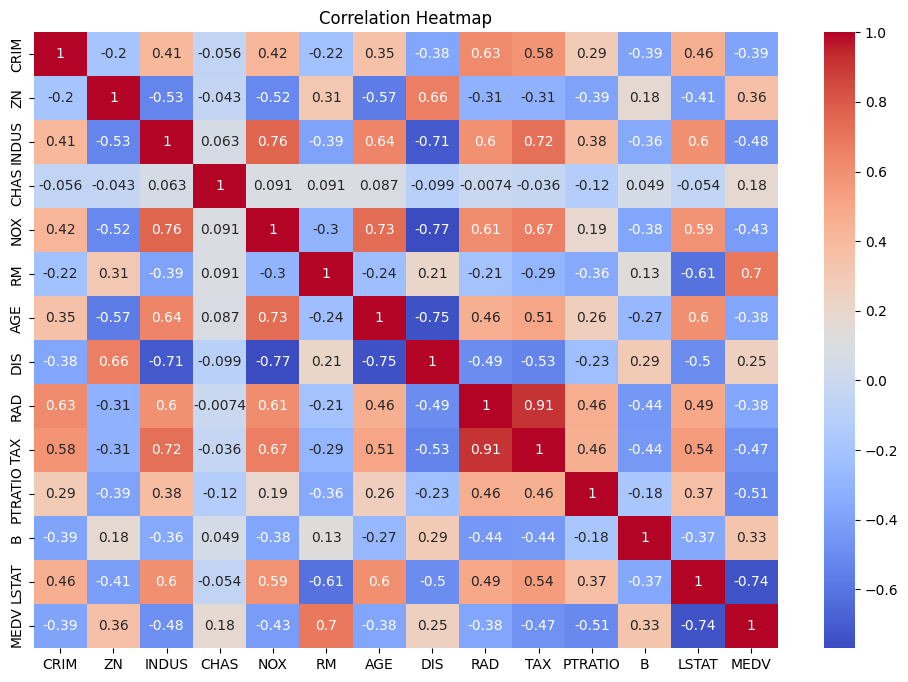

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## Step 7: Selecting Features and Target Variable

The target variable is MEDV, which represents the house price. All other columns are used as input features.

In [26]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (506, 13)
Target shape: (506,)


## Step 8: Splitting the Dataset

The dataset is split into training and testing sets. The training data is used to train the model, and the testing data is used to evaluate model performance.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (404, 13)
Testing data: (102, 13)


## Step 9: Training the Linear Regression Model

A Linear Regression model is trained using the training dataset.

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Step 10: Making Predictions

The trained model is used to predict house prices for the testing dataset.


In [30]:
y_pred = model.predict(X_test)
y_pred[:10]

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597])

## Step 11: Model Evaluation

The model is evaluated using Mean Squared Error and R-squared score.

In [31]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Squared Error: 24.291119474973478
R-squared Score: 0.6687594935356326


## Step 12: Comparing Actual and Predicted Values

This table compares the actual house prices with the predicted house prices.

In [32]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
comparison.head()

,Actual Price,Predicted Price
0,23.6,28.996724
1,32.4,36.025565
2,13.6,14.816944
3,22.8,25.031979
4,16.1,18.769880


## Step 13: Actual vs Predicted Price Visualization

A scatter plot is created to compare actual house prices with predicted house prices.

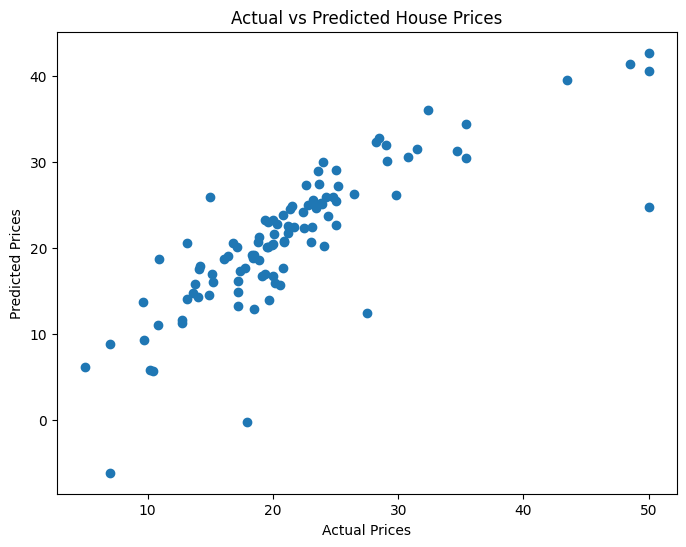

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

### Interpretation of the Scatter Plot

The scatter plot shows the relationship between actual house prices and predicted house prices.

Most data points follow an upward trend, indicating that the Linear Regression model was able to capture the relationship between input features and house prices reasonably well.

Some prediction errors and outliers are visible, which is expected in real-world datasets. Overall, the model demonstrates acceptable predictive performance for this regression analysis task.

## Step 14: Model Coefficients

The coefficients show how each feature affects the predicted house price.

In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,CRIM,-0.113056
1,ZN,0.030110
2,INDUS,0.040381
3,CHAS,2.784438
4,NOX,-17.202633
5,RM,4.438835
6,AGE,-0.006296
7,DIS,-1.447865
8,RAD,0.262430
9,TAX,-0.010647


# Conclusion

In this Level 2 regression analysis project, I built a Linear Regression model to predict house prices using the house prediction dataset.

First, I loaded the dataset and added appropriate column names. Then, I explored the dataset, checked for missing values, and analyzed correlations between features.

After that, I selected MEDV as the target variable and used the remaining columns as input features. The dataset was split into training and testing sets, and a Linear Regression model was trained.

The model was evaluated using Mean Squared Error and R-squared score. Finally, actual and predicted house prices were compared using a table and scatter plot.

This project helped demonstrate how regression analysis can be used to predict continuous numerical values such as house prices.